# EDA - PPE Detection Dataset

Analiza exploratorie a datelor pentru proiectul de detectie a echipamentului de protectie (PPE).

**Dataset:** [PPE Kit Detection - Kaggle](https://www.kaggle.com/datasets/ketakichalke/ppe-kit-detection-construction-site-workers)

**Format:** YOLO (bounding boxes normalizate, un fisier `.txt` per imagine)

**Nota importanta:** `data.yaml`-ul original de pe Kaggle avea `nc: 9` dar lista 10 nume de clase.
Investigatia din Pasul 2 a aratat ca exista de fapt **11 clase** (id-uri 0-10) in etichete.
Clasa lipsa (id 10) a fost identificata VIZUAL ca fiind "maini fara manusi" si denumita `NO_Gloves`.
Acest notebook porneste de la `data.yaml`-ul deja corectat.

In [37]:
import glob
import os
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# path-uri relative la acest notebook (notebooks/ -> radacina proiectului -> data_raw)
DATA_ROOT = "../data_raw"
YAML_PATH = "../data.yaml"
SPLITS = ["train", "val", "test"]

## 1. Incarcare configuratie (`data.yaml`) si clase

In [38]:
with open(YAML_PATH) as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]

print(f"Numar de clase (nc): {NUM_CLASSES}")
print("Nume clase:")
for cls_id, name in CLASS_NAMES.items():
    print(f"  {cls_id}: {name}")

Numar de clase (nc): 11
Nume clase:
  0: Helmet
  1: Safety_Vest
  2: Safety_goggles
  3: Safety_shoes
  4: NO_helmet
  5: NO_Vest
  6: NO_goggles
  7: No_SafetyShoes
  8: Person
  9: Slippers
  10: NO_Gloves


## 2. Inventar general - numar de imagini si etichete per split

In [39]:
def list_images(split):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.webp", "*.jfif")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(DATA_ROOT, split, "images", ext)))
    return files

def list_labels(split):
    return glob.glob(os.path.join(DATA_ROOT, split, "labels", "*.txt"))

inventory = []
for split in SPLITS:
    imgs = list_images(split)
    lbls = list_labels(split)
    inventory.append({
        "split": split,
        "nr_imagini": len(imgs),
        "nr_etichete": len(lbls),
    })

df_inventory = pd.DataFrame(inventory)
df_inventory["procent"] = (df_inventory["nr_imagini"] / df_inventory["nr_imagini"].sum() * 100).round(1)
df_inventory

,split,nr_imagini,nr_etichete,procent
0,train,10870,10870,70.0
1,val,3100,3100,20.0
2,test,1552,1552,10.0


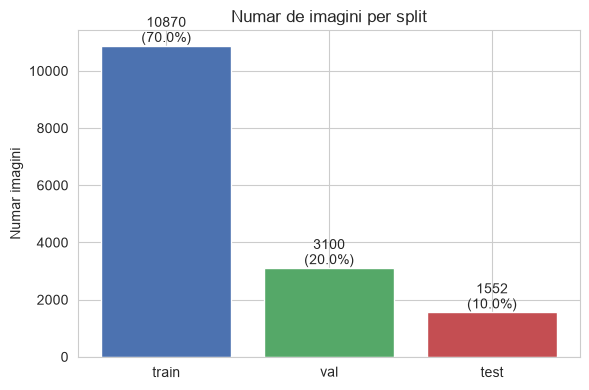

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_inventory["split"], df_inventory["nr_imagini"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Numar de imagini per split")
ax.set_ylabel("Numar imagini")
for i, v in enumerate(df_inventory["nr_imagini"]):
    ax.text(i, v, f"{v}\n({df_inventory['procent'][i]}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Rezolutia imaginilor

Verificam daca imaginile au dimensiuni consistente (util pentru a decide `imgsz` la antrenare).

In [41]:
# esantion - verificam pe un subset (500 img) din train, ca sa nu dureze prea mult
sample_imgs = list_images("train")[:500]
resolutions = []
for path in sample_imgs:
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        resolutions.append((w, h))

df_res = pd.DataFrame(resolutions, columns=["width", "height"])
print(f"Esantion analizat: {len(df_res)} imagini")
print(f"Latime  - min: {df_res.width.min()}, max: {df_res.width.max()}, medie: {df_res.width.mean():.0f}")
print(f"Inaltime - min: {df_res.height.min()}, max: {df_res.height.max()}, medie: {df_res.height.mean():.0f}")
print(f"\nNumar rezolutii distincte: {df_res.drop_duplicates().shape[0]}")
df_res.value_counts().head(10)

Esantion analizat: 500 imagini
Latime  - min: 136, max: 4032, medie: 1660
Inaltime - min: 102, max: 4160, medie: 977

Numar rezolutii distincte: 46


width  height
1920   1080      341
1280   720        43
612    408        31
4032   3024       14
500    333        13
       375         7
       334         6
       332         3
450    300         2
500    331         2
Name: count, dtype: int64

## 4. Distributia claselor (dezechilibru de clase)

Numaram de cate ori apare fiecare clasa in etichetele din `train/`.

In [42]:
def count_classes(split):
    counts = Counter()
    for label_path in list_labels(split):
        with open(label_path) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls_id = int(line.split()[0])
                    counts[cls_id] += 1
    return counts

class_counts_train = count_classes("train")

df_classes = pd.DataFrame([
    {"class_id": cid, "nume": CLASS_NAMES[cid], "aparitii": class_counts_train.get(cid, 0)}
    for cid in sorted(CLASS_NAMES.keys())
]).sort_values("aparitii", ascending=False)

df_classes

,class_id,nume,aparitii
0,0,Helmet,43196
8,8,Person,41745
5,5,NO_Vest,35112
3,3,Safety_shoes,26297
4,4,NO_helmet,7966
1,1,Safety_Vest,2792
6,6,NO_goggles,2297
7,7,No_SafetyShoes,1982
10,10,NO_Gloves,967
9,9,Slippers,738


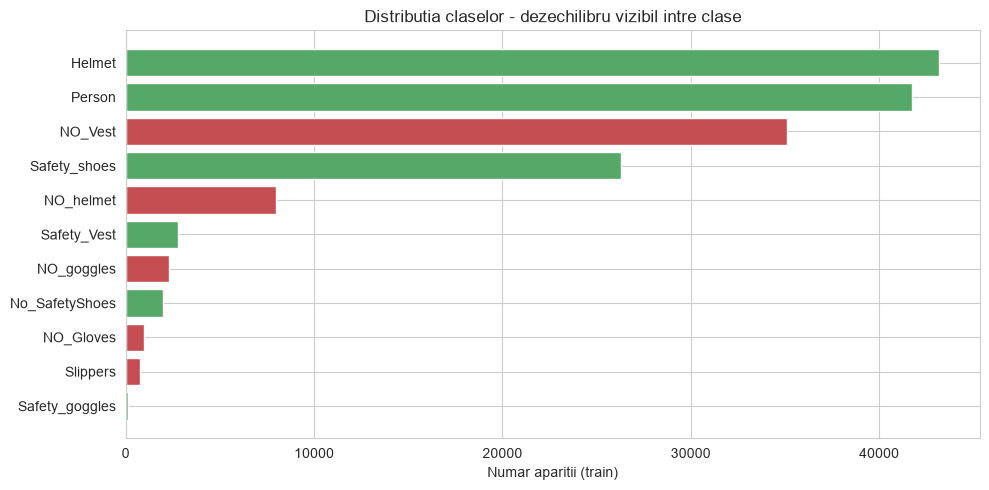

Observatie: clasele 'compliant' (Helmet, Person, Safety_shoes) domina,
iar Safety_goggles are cele mai putine exemple - risc de performanta slaba pe aceasta clasa.


In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if "NO" in n or n == "Slippers" else "#55A868" for n in df_classes["nume"]]
ax.barh(df_classes["nume"], df_classes["aparitii"], color=colors)
ax.set_xlabel("Numar aparitii (train)")
ax.set_title("Distributia claselor - dezechilibru vizibil intre clase")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Observatie: clasele 'compliant' (Helmet, Person, Safety_shoes) domina,")
print("iar Safety_goggles are cele mai putine exemple - risc de performanta slaba pe aceasta clasa.")

## 5. Verificare valori lipsa / erori de date

- imagini fara fisier de etichete corespunzator
- fisiere de etichete goale (fara nicio adnotare)
- bounding box-uri invalide (coordonate in afara intervalului [0, 1], latime/inaltime 0)

In [44]:
def check_data_quality(split):
    img_files = list_images(split)
    img_basenames = {os.path.splitext(os.path.basename(p))[0] for p in img_files}
    label_files = list_labels(split)
    label_basenames = {os.path.splitext(os.path.basename(p))[0] for p in label_files}

    imgs_fara_label = img_basenames - label_basenames
    labels_fara_img = label_basenames - img_basenames

    empty_labels = 0
    invalid_boxes = []
    for label_path in label_files:
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if len(lines) == 0:
            empty_labels += 1
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                invalid_boxes.append((label_path, "linie incompleta"))
                continue
            _, xc, yc, bw, bh = parts[:5]
            xc, yc, bw, bh = float(xc), float(yc), float(bw), float(bh)
            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                invalid_boxes.append((label_path, "coordonate in afara [0,1]"))
            if bw <= 0 or bh <= 0:
                invalid_boxes.append((label_path, "latime/inaltime 0"))

    return {
        "split": split,
        "imagini_fara_eticheta": len(imgs_fara_label),
        "etichete_fara_imagine": len(labels_fara_img),
        "etichete_goale": empty_labels,
        "bounding_box_invalide": len(invalid_boxes),
    }

quality_report = [check_data_quality(s) for s in SPLITS]
df_quality = pd.DataFrame(quality_report)
df_quality

,split,imagini_fara_eticheta,etichete_fara_imagine,etichete_goale,bounding_box_invalide
0,train,0,0,32,0
1,val,0,0,0,0
2,test,0,0,32,0


**Interpretare:** daca toate coloanele sunt 0 (sau foarte aproape de 0), datele sunt curate
structural si putem continua fara pasi suplimentari de curatare. Daca apar valori mari,
trebuie decis: eliminam acele fisiere, sau le reparam manual, inainte de Pasul 6 (pipeline).

## 6. Caracteristicile bounding box-urilor

Aspect ratio, dimensiune relativa, si numar de obiecte per imagine.

In [45]:
box_records = []
objects_per_image = []

for label_path in list_labels("train"):
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    objects_per_image.append(len(lines))
    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        box_records.append({
            "class_id": cls_id,
            "nume": CLASS_NAMES[cls_id],
            "width": bw,
            "height": bh,
            "area": bw * bh,
            "aspect_ratio": bw / bh if bh > 0 else 0,
        })

df_boxes = pd.DataFrame(box_records)
df_boxes.describe()

,class_id,width,height,area,aspect_ratio
count,163238.000000,163238.000000,163238.000000,163238.000000,163238.000000
mean,4.088062,0.031758,0.069686,0.007423,0.560002
std,3.056708,0.071242,0.101425,0.046223,0.351776
min,0.000000,0.002401,0.002282,0.000005,0.052840
25%,0.000000,0.011703,0.018069,0.000225,0.318489
50%,5.000000,0.017336,0.036903,0.000620,0.510084
75%,8.000000,0.027634,0.074889,0.002272,0.733056
max,10.000000,1.000000,1.000000,1.000000,9.605658


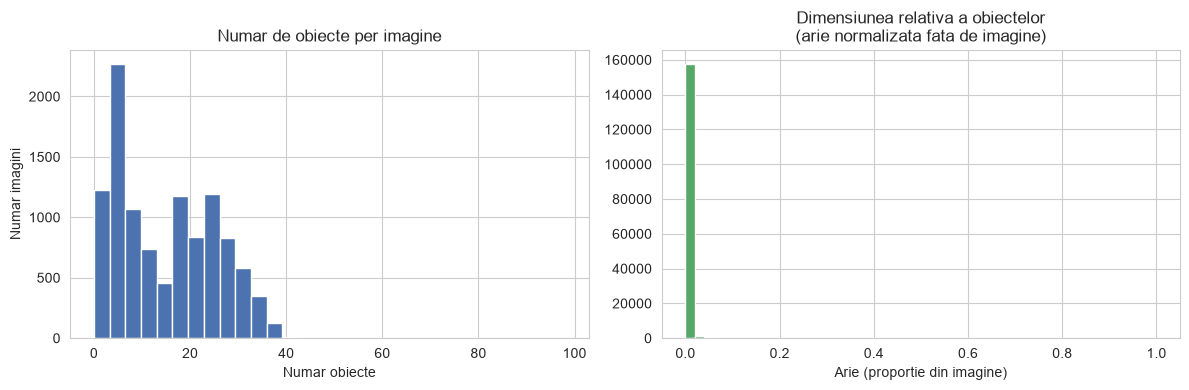

Media obiecte/imagine: 15.0
Max obiecte intr-o imagine: 98


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(objects_per_image, bins=30, color="#4C72B0")
axes[0].set_title("Numar de obiecte per imagine")
axes[0].set_xlabel("Numar obiecte")
axes[0].set_ylabel("Numar imagini")

axes[1].hist(df_boxes["area"], bins=50, color="#55A868")
axes[1].set_title("Dimensiunea relativa a obiectelor\n(arie normalizata fata de imagine)")
axes[1].set_xlabel("Arie (proportie din imagine)")

plt.tight_layout()
plt.show()

print(f"Media obiecte/imagine: {np.mean(objects_per_image):.1f}")
print(f"Max obiecte intr-o imagine: {np.max(objects_per_image)}")

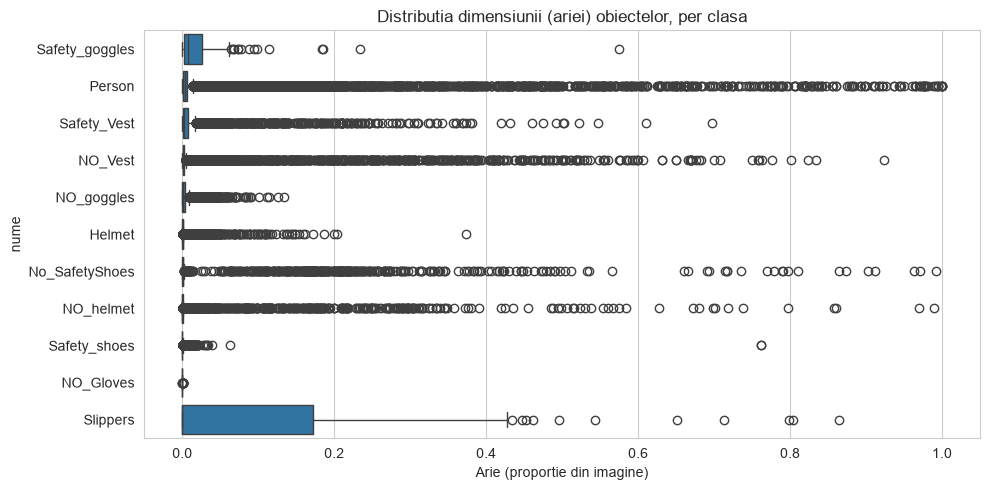

In [47]:
# dimensiunea (aria) medie a obiectelor, per clasa - unele clase (ex. goggles) sunt
# sistematic mai mici -> mai greu de detectat
fig, ax = plt.subplots(figsize=(10, 5))
order = df_boxes.groupby("nume")["area"].median().sort_values(ascending=False).index
sns.boxplot(data=df_boxes, y="nume", x="area", order=order, ax=ax)
ax.set_title("Distributia dimensiunii (ariei) obiectelor, per clasa")
ax.set_xlabel("Arie (proportie din imagine)")
plt.tight_layout()
plt.show()

## 7. Corelatii - co-aparitia claselor

Cat de des apar doua clase impreuna, in aceeasi imagine (ex. `Person` + `Helmet`).

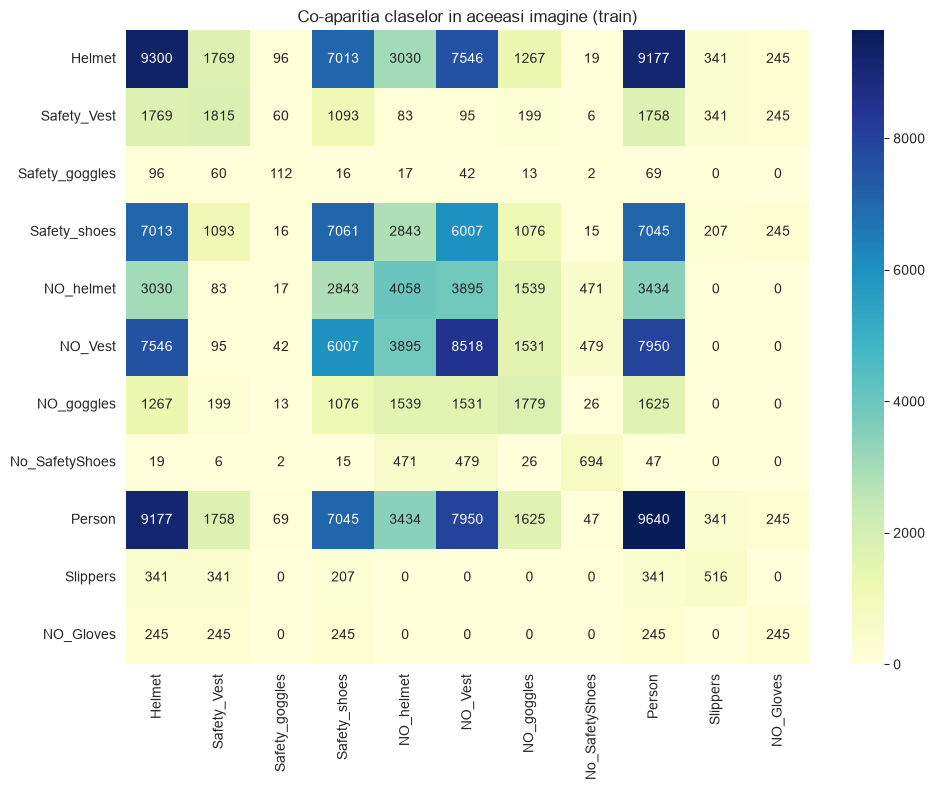

In [48]:
class_ids_sorted = sorted(CLASS_NAMES.keys())
co_occurrence = pd.DataFrame(0, index=class_ids_sorted, columns=class_ids_sorted)

for label_path in list_labels("train"):
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    classes_in_image = set(int(l.split()[0]) for l in lines)
    for c1 in classes_in_image:
        for c2 in classes_in_image:
            co_occurrence.loc[c1, c2] += 1

co_occurrence.index = [CLASS_NAMES[i] for i in co_occurrence.index]
co_occurrence.columns = [CLASS_NAMES[i] for i in co_occurrence.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Co-aparitia claselor in aceeasi imagine (train)")
plt.tight_layout()
plt.show()

**Interpretare:** ne asteptam ca `Person` sa co-apara frecvent cu aproape toate celelalte
clase (echipamentul e purtat de o persoana). Daca vedem clase care NU co-apar aproape
deloc cu `Person`, poate fi un semnal de eroare de adnotare, de investigat separat.

## 8. Inspectie vizuala - mozaic de imagini cu adnotari

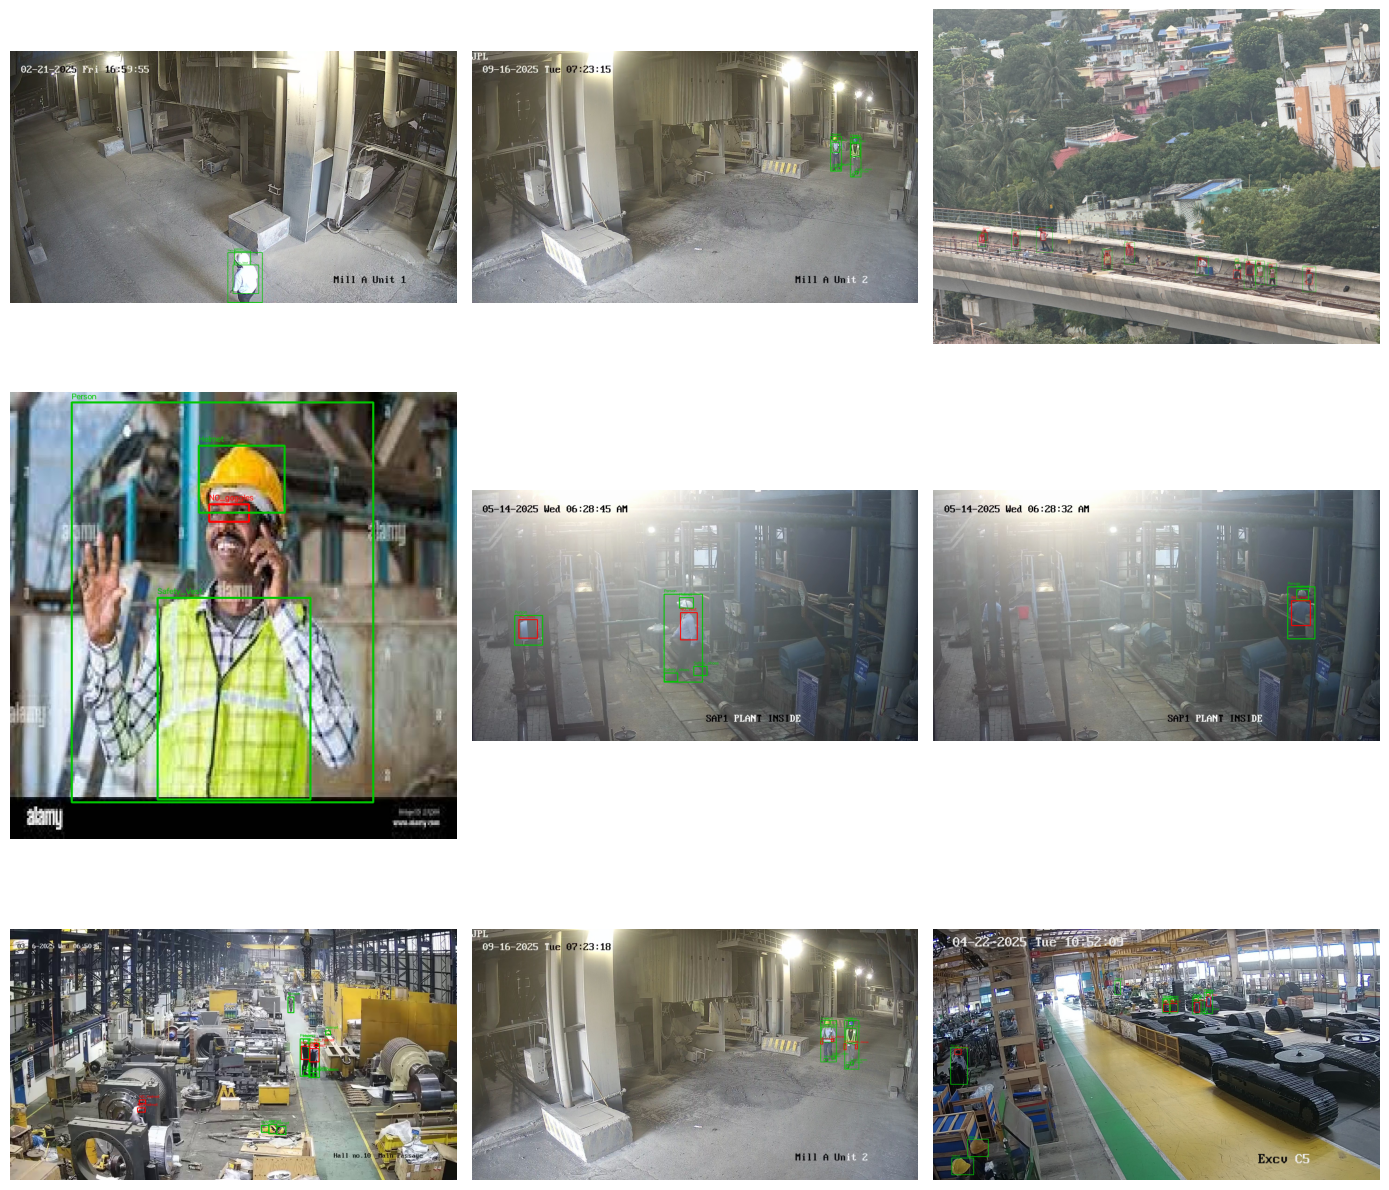

In [49]:
import random

random.seed(42)

def draw_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        color = (255, 0, 0) if "NO" in CLASS_NAMES[cls_id] else (0, 200, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cls_id], (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img

train_images = list_images("train")
sample = random.sample(train_images, min(9, len(train_images)))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for ax, img_path in zip(axes.flat, sample):
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(DATA_ROOT, "train", "labels", base + ".txt")
    if os.path.exists(label_path):
        img = draw_boxes(img_path, label_path)
        ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Concluzii EDA

_(de completat manual, pe baza rezultatelor de mai sus, inainte de a trece la Pasul 4)_

- Numar total de imagini / distributie train-val-test: ...
- Dezechilibru de clase observat: ...
- Probleme de calitate a datelor gasite: ...
- Clase cu obiecte foarte mici (posibil greu de detectat): ...
- Decizii care rezulta pentru pasii urmatori (augmentare, ponderare loss, etc.): ...